In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/vidhy/OneDrive/Pictures/Documents/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [20]:
df.shape

(1338, 7)

In [21]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [24]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [25]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
df1=df['sex'].value_counts()
df1

sex
male      676
female    662
Name: count, dtype: int64

<BarContainer object of 2 artists>

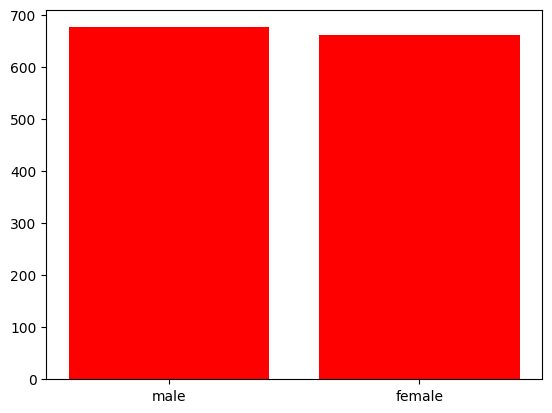

In [27]:
plt.bar(df1.index,df1.values,color='r')

In [28]:
df2=df['smoker'].value_counts()
df2

smoker
no     1064
yes     274
Name: count, dtype: int64

<BarContainer object of 2 artists>

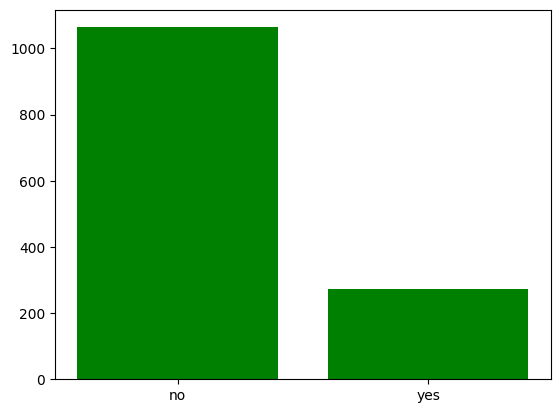

In [29]:
plt.bar(df2.index,df2.values,color='g')

In [30]:
df3=df['region'].value_counts()
df3

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

<BarContainer object of 4 artists>

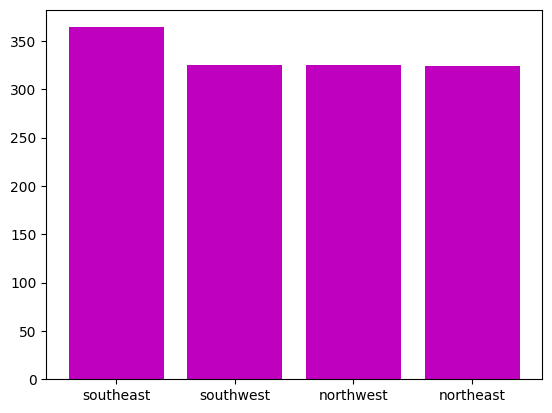

In [31]:
plt.bar(df3.index,df3.values,color='m')

In [32]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

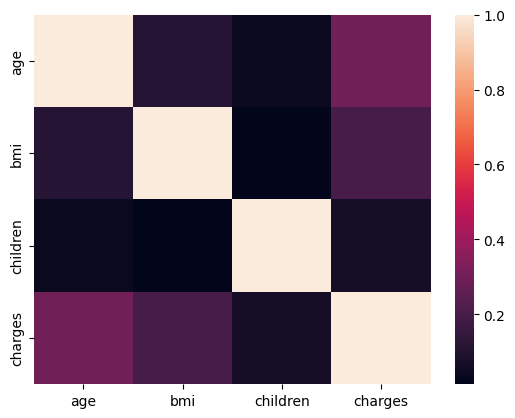

In [33]:
sns.heatmap(df.corr(numeric_only=True))

In [34]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [35]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

<Axes: xlabel='age', ylabel='charges'>

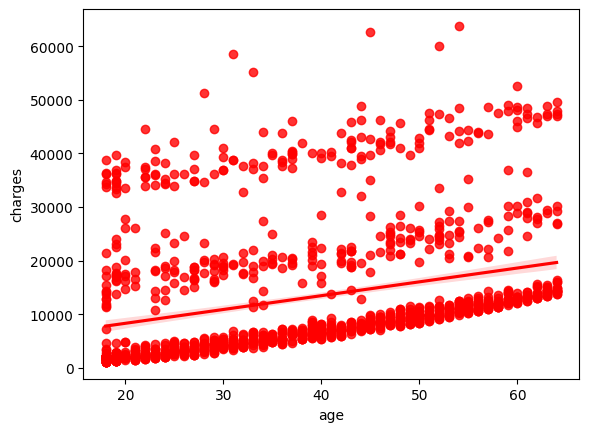

In [36]:
sns.regplot(x=df['age'],y=y,color='r')

<Axes: xlabel='bmi', ylabel='charges'>

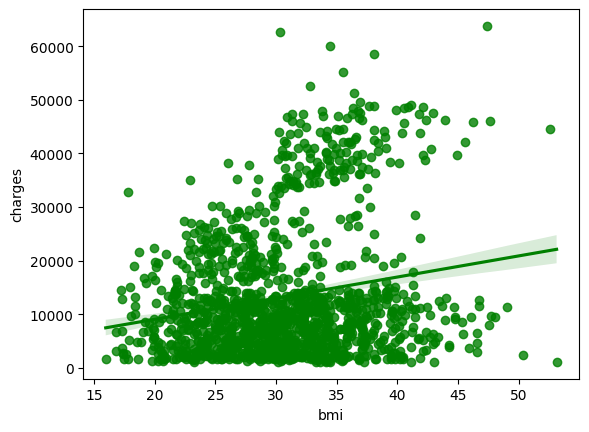

In [37]:
sns.regplot(x=df['bmi'],y=y,color='g')

<Axes: xlabel='children', ylabel='charges'>

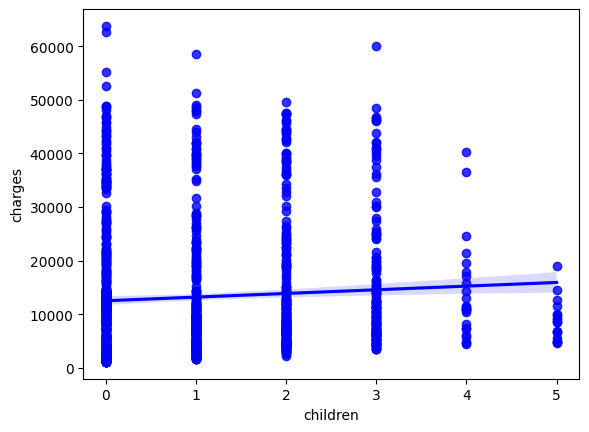

In [38]:
sns.regplot(x=df['children'],y=y,color='b')

In [40]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
col=make_column_transformer((OneHotEncoder(handle_unknown='ignore'),['sex','smoker','region']),remainder='passthrough')
x=col.fit_transform(x)
x

array([[ 1.  ,  0.  ,  0.  , ..., 19.  , 27.9 ,  0.  ],
       [ 0.  ,  1.  ,  1.  , ..., 18.  , 33.77,  1.  ],
       [ 0.  ,  1.  ,  1.  , ..., 28.  , 33.  ,  3.  ],
       ...,
       [ 1.  ,  0.  ,  1.  , ..., 18.  , 36.85,  0.  ],
       [ 1.  ,  0.  ,  1.  , ..., 21.  , 25.8 ,  0.  ],
       [ 1.  ,  0.  ,  0.  , ..., 61.  , 29.07,  0.  ]], shape=(1338, 11))

In [41]:
x.shape

(1338, 11)

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)
x_train

array([[ 1.   ,  0.   ,  1.   , ..., 61.   , 31.16 ,  0.   ],
       [ 0.   ,  1.   ,  1.   , ..., 46.   , 27.6  ,  0.   ],
       [ 1.   ,  0.   ,  1.   , ..., 54.   , 31.9  ,  3.   ],
       ...,
       [ 0.   ,  1.   ,  1.   , ..., 58.   , 25.175,  0.   ],
       [ 1.   ,  0.   ,  0.   , ..., 37.   , 47.6  ,  2.   ],
       [ 0.   ,  1.   ,  1.   , ..., 55.   , 29.9  ,  0.   ]],
      shape=(936, 11))

In [43]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 9.01636753e+03,  7.01997635e+03,  3.68708343e+04,  9.51853774e+03,
        2.69740308e+04,  1.10808462e+04, -4.06177600e+01,  1.71922331e+04,
        9.74950536e+02,  1.13299594e+04,  2.80574861e+04,  9.47838799e+03,
        4.98095281e+03,  3.84564701e+04,  4.03433327e+04,  3.71038753e+04,
        1.51982019e+04,  3.57689693e+04,  8.88568387e+03,  3.13835989e+04,
        3.79641903e+03,  1.02628964e+04,  2.37593679e+03,  7.26280819e+03,
        1.12875675e+04,  1.31383480e+04,  1.46241614e+04,  6.07324604e+03,
        1.00361537e+04,  1.97927814e+03,  9.07103928e+03,  1.31369887e+04,
        4.30868680e+03,  3.21105955e+03,  4.48957162e+03,  1.33774493e+04,
        1.82221028e+03,  8.79191682e+03,  3.31981518e+04,  3.25005781e+04,
        3.76368816e+03,  4.35479656e+03,  1.42473276e+04,  1.15436019e+04,
        8.70433805e+03,  1.22401028e+04,  5.20831471e+03,  2.98293172e+03,
        3.54465532e+04,  9.10285846e+03,  1.57820945e+04,  2.13473894e+03,
        1.24668220e+04,  

In [45]:
df4=pd.DataFrame({'actual value':y_test,'predicted value':y_pred,'difference':y_test-y_pred})
df4

,actual value,predicted value,difference
764,9095.06825,9016.367529,78.700721
887,5272.17580,7019.976349,-1747.800549
890,29330.98315,36870.834268,-7539.851118
1293,9301.89355,9518.537736,-216.644186
259,33750.29180,26974.030822,6776.260978
...,...,...,...
701,9541.69555,16302.722223,-6761.026673
672,4399.73100,6529.103731,-2129.372731
1163,2200.83085,2173.789343,27.041507
1103,11363.28320,14503.662181,-3140.378981


In [46]:
print(model.coef_)

[   -52.40591149     52.40591149 -11814.18361118  11814.18361118
    596.05658924    109.12197876   -374.91224933   -330.26631867
    261.29692414    348.90691516    424.11912829]


In [47]:
print(model.intercept_)

-1103.4309695994234


In [48]:
from sklearn.metrics import mean_absolute_percentage_error,r2_score
mape=mean_absolute_percentage_error(y_test,y_pred)
mape

0.43585625991943555

In [49]:
score=r2_score(y_test,y_pred)
score

0.7696118054369009